# 📉 Dijkstra – Rapport de Visualisation

Ce notebook reproduit le graphe utilisé dans `dijkstra_tp.py`, affiche le graphe visuellement et met en évidence le **chemin le plus court** trouvé par l'algorithme de Dijkstra.


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


## 1️⃣ Construction du graphe

In [2]:
# Création du graphe avec NetworkX
G = nx.Graph()

# Ajout des sommets
nodes = ['a', 'b', 'c', 'd', 'e', 'f']
G.add_nodes_from(nodes)

# Ajout des arêtes avec poids
edges = [
    ('a', 'b', 7),
    ('a', 'c', 9),
    ('a', 'f', 14),
    ('b', 'c', 10),
    ('b', 'd', 15),
    ('c', 'd', 11),
    ('c', 'f', 2),
    ('d', 'e', 6),
    ('e', 'f', 9),
]
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

print("Sommets:", list(G.nodes()))
print("Arêtes avec poids:")
for u, v, d in G.edges(data=True):
    print(f"  {u} -- {v} : {d['weight']}")


Sommets: ['a', 'b', 'c', 'd', 'e', 'f']
Arêtes avec poids:
  a -- b : 7
  a -- c : 9
  a -- f : 14
  b -- c : 10
  b -- d : 15
  c -- d : 11
  c -- f : 2
  d -- e : 6
  e -- f : 9


## 2️⃣ Exécution de Dijkstra

In [3]:
# Dijkstra avec NetworkX
shortest_path = nx.dijkstra_path(G, 'a', 'e', weight='weight')
shortest_length = nx.dijkstra_path_length(G, 'a', 'e', weight='weight')

print("🏁 Chemin le plus court de 'a' à 'e':", shortest_path)
print("📏 Distance totale:", shortest_length)


🏁 Chemin le plus court de 'a' à 'e': ['a', 'c', 'f', 'e']
📏 Distance totale: 20


## 3️⃣ Visualisation du graphe

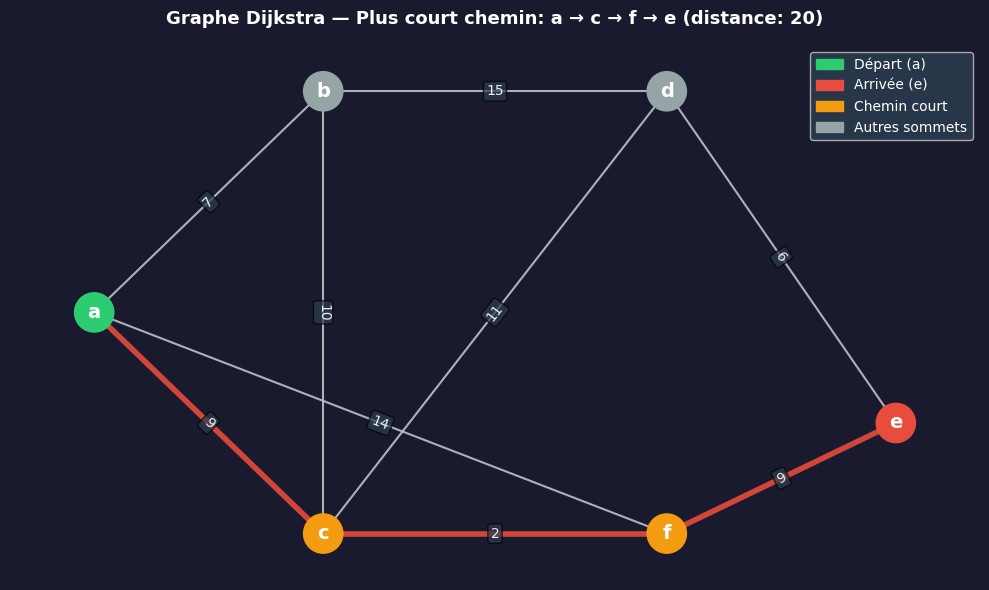

✅ Graphe sauvegardé sous 'dijkstra_graph.png'


In [4]:
# Positions fixes pour un graphe lisible
pos = {
    'a': (0, 1),
    'b': (1, 2),
    'c': (1, 0),
    'd': (2.5, 2),
    'e': (3.5, 0.5),
    'f': (2.5, 0),
}

# Chemin le plus court
path_edges = list(zip(shortest_path[:-1], shortest_path[1:]))
path_nodes = shortest_path

# Couleurs des noeuds
node_colors = []
for node in G.nodes():
    if node == 'a':
        node_colors.append('#2ecc71')   # départ = vert
    elif node == 'e':
        node_colors.append('#e74c3c')   # arrivée = rouge
    elif node in path_nodes:
        node_colors.append('#f39c12')   # chemin = orange
    else:
        node_colors.append('#95a5a6')   # autres = gris

# Couleurs des arêtes
edge_colors = []
edge_widths = []
for u, v in G.edges():
    if (u, v) in path_edges or (v, u) in path_edges:
        edge_colors.append('#e74c3c')
        edge_widths.append(4.0)
    else:
        edge_colors.append('#bdc3c7')
        edge_widths.append(1.5)

# Dessin
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

# Arêtes
nx.draw_networkx_edges(G, pos, ax=ax,
    edge_color=edge_colors,
    width=edge_widths,
    alpha=0.9)

# Noeuds
nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=node_colors,
    node_size=800,
    alpha=1.0)

# Labels des noeuds
nx.draw_networkx_labels(G, pos, ax=ax,
    font_color='white',
    font_size=14,
    font_weight='bold')

# Labels des poids
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
    font_color='#ecf0f1',
    font_size=10,
    bbox=dict(boxstyle='round,pad=0.2', facecolor='#2c3e50', alpha=0.7))

# Légende
legend_elements = [
    mpatches.Patch(color='#2ecc71', label='Départ (a)'),
    mpatches.Patch(color='#e74c3c', label='Arrivée (e)'),
    mpatches.Patch(color='#f39c12', label='Chemin court'),
    mpatches.Patch(color='#95a5a6', label='Autres sommets'),
]
ax.legend(handles=legend_elements, loc='upper right',
          facecolor='#2c3e50', labelcolor='white', fontsize=10)

ax.set_title(f"Graphe Dijkstra — Plus court chemin: {' → '.join(shortest_path)} (distance: {shortest_length})",
             color='white', fontsize=13, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig('dijkstra_graph.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ Graphe sauvegardé sous 'dijkstra_graph.png'")


## 4️⃣ Tableau des distances depuis 'a'

In [5]:
# Distances de tous les sommets depuis 'a'
lengths = nx.single_source_dijkstra_path_length(G, 'a', weight='weight')
paths = nx.single_source_dijkstra_path(G, 'a', weight='weight')

print(f"{'Sommet':<10} {'Distance':<12} {'Chemin'}")
print("-" * 40)
for node in sorted(lengths):
    path_str = ' → '.join(paths[node])
    print(f"  {node:<10} {lengths[node]:<12} {path_str}")


Sommet     Distance     Chemin
----------------------------------------
  a          0            a
  b          7            a → b
  c          9            a → c
  d          20           a → c → d
  e          20           a → c → f → e
  f          11           a → c → f
